In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import layers, losses, Model
from random import randint

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

noise_factor = 0.4
x_train_noisy = x_train + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_train.shape)
x_test_noisy = x_test + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_test.shape)
x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

In [3]:
input_layer = layers.Input(shape=(28, 28))
flattened = layers.Flatten()(input_layer)
hidden = layers.Dense(100, activation='relu')(flattened)
latent = layers.Dense(20, activation='relu')(hidden)
encoder = Model(inputs=input_layer, outputs=latent, name='encoder')

In [4]:
input_layer_decoder = layers.Input(shape=(20,))
upsampled = layers.Dense(100, activation='relu')(input_layer_decoder)
upsampled2 = layers.Dense(784, activation='sigmoid')(upsampled)
constructed = layers.Reshape((28, 28))(upsampled2)
decoder = Model(inputs=input_layer_decoder, outputs=constructed, name='decoder')

In [5]:
autoencoder = Model(inputs=encoder.input, outputs=decoder(encoder.output))
autoencoder.compile(optimizer='adam', loss=losses.MeanSquaredError(), metrics=['accuracy'])
history = autoencoder.fit(x_train_noisy, x_train, epochs=5, batch_size=32, validation_data=(x_test_noisy, x_test))


Epoch 1/5


1875/1875 [==============================] - 12s 5ms/step - loss: 0.0414 - accuracy: 0.1608 - val_loss: 0.0319 - val_accuracy: 0.1931
Epoch 2/5
1875/1875 [==============================] - 8s 4ms/step - loss: 0.0302 - accuracy: 0.2011 - val_loss: 0.0279 - val_accuracy: 0.2070
Epoch 3/5
1875/1875 [==============================] - 9s 5ms/step - loss: 0.0273 - accuracy: 0.2139 - val_loss: 0.0257 - val_accuracy: 0.2179
Epoch 4/5
1875/1875 [==============================] - 9s 5ms/step - loss: 0.0251 - accuracy: 0.2216 - val_loss: 0.0241 - val_accuracy: 0.2180
Epoch 5/5
1875/1875 [==============================] - 8s 5ms/step - loss: 0.0237 - accuracy: 0.2274 - val_loss: 0.0230 - val_accuracy: 0.2224


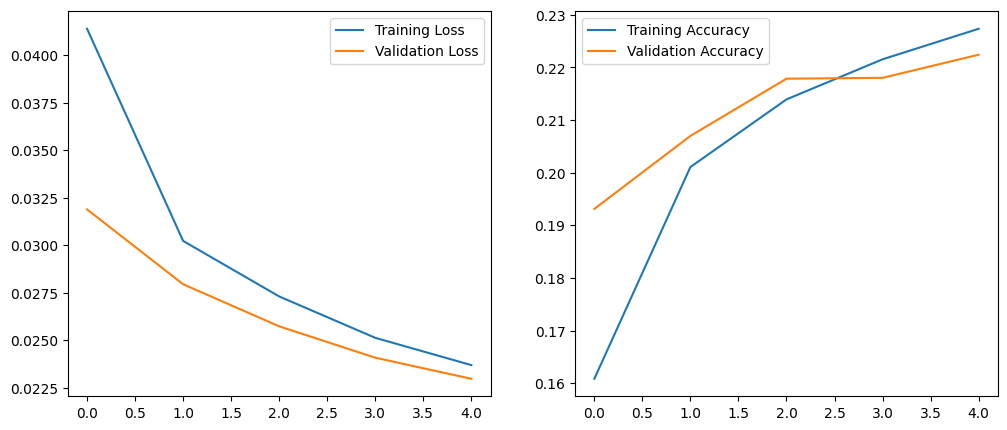

In [6]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.show()

1/1 [==============================] - 0s 48ms/step


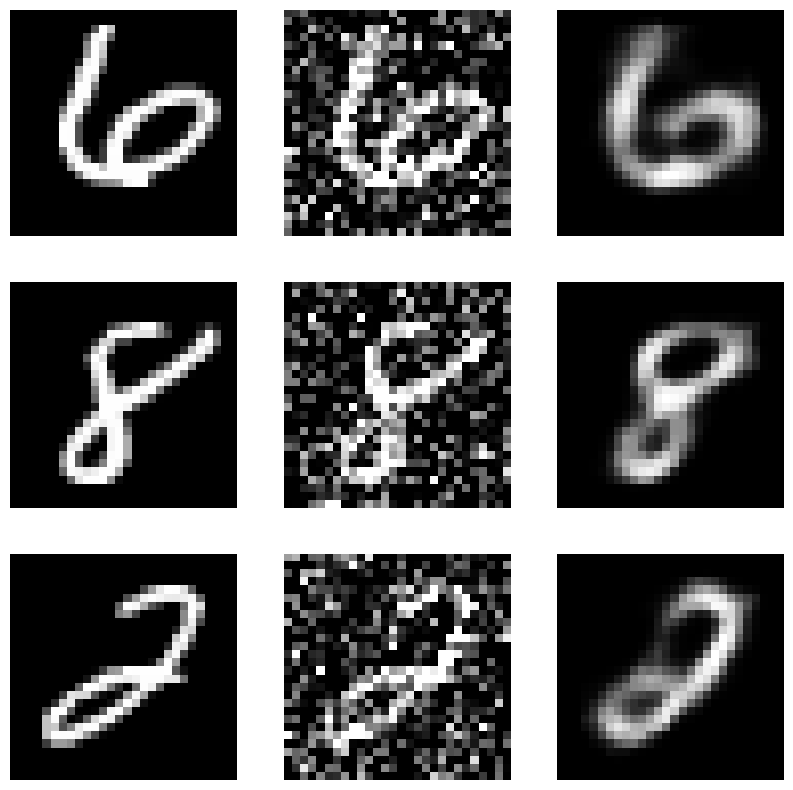

In [7]:
fig, axs = plt.subplots(3, 3, figsize=(10, 10))
for i in range(3):
    idx = randint(0, x_test.shape[0])
    sample = x_test_noisy[idx]
    reconstructed = autoencoder.predict(np.expand_dims(sample, 0))[0]
    axs[i][0].imshow(x_test[idx], cmap='gray')
    axs[i][1].imshow(sample, cmap='gray')
    axs[i][2].imshow(reconstructed, cmap='gray')
    for j in range(3):
        axs[i][j].axis('off')
plt.show()